<a href="https://colab.research.google.com/github/giovannadb/transfer-learning-cat-vs-dog/blob/main/cat_vs_dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning para reconhecimento de gatos e cachorros

In [9]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from time import time
from torchvision import datasets, transforms
from torch import nn, optim
import os


In [10]:

# Clonagem do repositório do github que contém as imagens cat vs dogs
!git clone https://github.com/giovannadb/dataset-cat-vs-dog.git

# Define o caminho base para o dataset depois de clonado
dataset_base_path = './dataset-cat-vs-dog/pet-Images'


Cloning into 'dataset-cat-vs-dog'...
remote: Enumerating objects: 436, done.
remote: Counting objects: 100% (436/436), done.
remote: Compressing objects: 100% (434/434), done.
remote: Total 436 (delta 1), reused 435 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (436/436), 24.90 MiB | 33.33 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [11]:
!ls -R dataset-cat-vs-dog

dataset-cat-vs-dog:
cat-vs-dog.py  pet-Images  teste.txt

dataset-cat-vs-dog/pet-Images:
Cat  Dog

dataset-cat-vs-dog/pet-Images/Cat:
0.jpg	 121.jpg  143.jpg  165.jpg  187.jpg  208.jpg  40.jpg  62.jpg  84.jpg
100.jpg  122.jpg  144.jpg  166.jpg  188.jpg  209.jpg  41.jpg  63.jpg  85.jpg
101.jpg  123.jpg  145.jpg  167.jpg  189.jpg  20.jpg   42.jpg  64.jpg  86.jpg
102.jpg  124.jpg  146.jpg  168.jpg  18.jpg   21.jpg   43.jpg  65.jpg  87.jpg
103.jpg  125.jpg  147.jpg  169.jpg  190.jpg  22.jpg   44.jpg  66.jpg  88.jpg
104.jpg  126.jpg  148.jpg  16.jpg   191.jpg  23.jpg   45.jpg  67.jpg  89.jpg
105.jpg  127.jpg  149.jpg  170.jpg  192.jpg  24.jpg   46.jpg  68.jpg  8.jpg
106.jpg  128.jpg  14.jpg   171.jpg  193.jpg  25.jpg   47.jpg  69.jpg  90.jpg
107.jpg  129.jpg  150.jpg  172.jpg  194.jpg  26.jpg   48.jpg  6.jpg   91.jpg
108.jpg  12.jpg   151.jpg  173.jpg  195.jpg  27.jpg   49.jpg  70.jpg  92.jpg
109.jpg  130.jpg  152.jpg  174.jpg  196.jpg  28.jpg   4.jpg   71.jpg  93.jpg
10.jpg	 131.jpg  153.j

In [12]:
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize as imagens para o tamanho comum
    transforms.ToTensor(),         # Converte a imagem para tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normaliza a imagem
])

# Carrega todo o dataset do diretório pet images
full_dataset = torchvision.datasets.ImageFolder(dataset_base_path, transform=transform)

# Define a proporção de divisão (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Divide o dataset entre treinamento e validação conjunta
trainset, valset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

# Cria um carregamento de dados para treinamento e validação
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True) #cria um buffer para pegar os dados por partes
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=True) #cria um buffer para pegar os dados por partes

print(f"Number of training samples: {len(trainset)}")
print(f"Number of validation samples: {len(valset)}")
print(f"Classes: {full_dataset.classes}")

Number of training samples: 340
Number of validation samples: 86
Classes: ['Cat', 'Dog']


Label: Dog


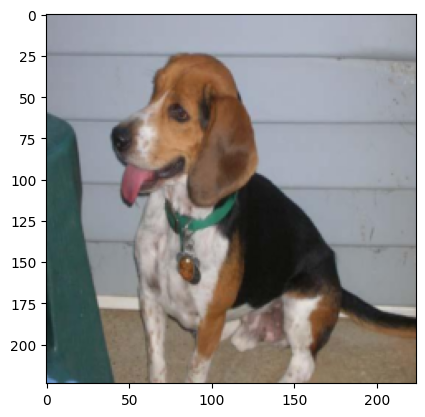

In [13]:
dataiter = iter(trainloader)
imagens, etiquetas = next(dataiter)

# Pega uma imagem e seu rótulo
image = imagens[0]
label = etiquetas[0]

# Define o mean e o std usado para normalização
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

# Desnormaliza a imagem
image_denormalized = image * std[:, None, None] + mean[:, None, None]
# Clamp valores para [0, 1] para garantir que que eles estão entre uma faixa válida para plotting
image_denormalized = torch.clamp(image_denormalized, 0, 1)

# Transpor a dimensão da imagem de (C, H, W) para (H, W, C) para o matplotlib
plt.imshow(image_denormalized.permute(1, 2, 0).numpy());

# Mostrar o rótulo
print(f"Label: {full_dataset.classes[label]}")

In [14]:
print(imagens[0].shape) #verifica as dimensões do tensor de cada imagem
print(etiquetas[0].shape) #verifica as dimensões do tensor de cada etiqueta

torch.Size([3, 224, 224])
torch.Size([])


Modelo VGG16 para transfer learning

In [15]:
import torchvision.models as models
from torch import nn, optim

class Modelo(nn.Module):
  def __init__(self):
    super(Modelo, self).__init__()
    # Carrega um modelo VGG16 pré-treinado
    self.vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

    # Congela os parâmetros do VGG16 para que não sejam atualizados durante o treinamento
    for param in self.vgg.features.parameters():
      param.requires_grad = False

    # Substitui o classificador padrão do VGG16 por um novo
    # O classificador original do VGG16 tem uma camada de entrada de 25088
    self.vgg.classifier = nn.Sequential(
        nn.Linear(self.vgg.classifier[0].in_features, 512), # Primeira camada linear com entrada do VGG e saída de 512 neurônios
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 2) # Camada de saída para 2 classes (Cat, Dog)
    )

  def forward(self, X):
    # O VGG espera uma entrada de 3 canais e 224x224
    X = self.vgg(X)
    return F.log_softmax(X, dim=1)

In [20]:
def treino(modelo, trainloader, device):

  # Apenas otimize os parâmetros do classificador (as features do VGG estão congeladas)
  otimizador = optim.Adam(modelo.vgg.classifier.parameters(), lr=0.001)
  inicio = time()

  criterio = nn.NLLLoss()
  EPOCHS = 3 # 3 para demonstração mais rápida
  modelo.train()

  for epoch in range(EPOCHS):
    perda_acumulada = 0

    for imagens, etiquetas in trainloader:
      otimizador.zero_grad()

      output = modelo(imagens.to(device))
      perda_instantanea = criterio(output, etiquetas.to(device))

      perda_instantanea.backward()

      otimizador.step()

      perda_acumulada += perda_instantanea.item()

  else:
    print("Epoch {} - perda resultante: {}".format(epoch+1, perda_acumulada/len(trainloader)))
  print("\nTempo de treino (em minutos) =", (time()-inicio)/60)

In [21]:
def validacao(modelo, valloader, device):
  modelo.eval() # Coloca o modelo em modo de avaliação (desativa dropout, batchnorm, etc.)
  conta_corretas, conta_todas = 0, 0
  with torch.no_grad(): # Desativa o cálculo de gradientes para acelerar a validação
    for imagens, etiquetas in valloader:

      logps = modelo(imagens.to(device))
      ps = torch.exp(logps)

      # Pega o índice da classe com a maior probabilidade
      _, etiqueta_pred = torch.max(ps, 1)

      # Compara as previsões com as etiquetas verdadeiras
      conta_todas += etiquetas.size(0) # Adiciona o número total de amostras no batch
      conta_corretas += (etiqueta_pred == etiquetas.to(device)).sum().item()

  print("Total de imagens testadas =", conta_todas)
  print("\nPrecisão do modelo = {}%".format(conta_corretas*100/conta_todas))

In [22]:
import torch

modelo = Modelo() #inicia o modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #modelo rodará na GPU se possível #leitura do Pytorch na versão cuda se disponível (placa de vídeo nvidia)
modelo.to(device)

Modelo(
  (vgg): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      (16): Max

In [23]:
treino(modelo, trainloader, device)

Epoch 3 - perda resultante: 0.028983134356773615

Tempo de treino (em minutos) = 12.316036272048951


In [24]:
validacao(modelo, valloader, device)

Total de imagens testadas = 86

Precisão do modelo = 97.67441860465117%


### Análise da Matriz de Confusão

*   **Verdadeiros Positivos (TP):** O modelo previu 'Cat' e era realmente 'Cat'.
*   **Verdadeiros Negativos (TN):** O modelo previu 'Dog' e era realmente 'Dog'.
*   **Falsos Positivos (FP):** O modelo previu 'Cat' mas era 'Dog' (Erro Tipo I).
*   **Falsos Negativos (FN):** O modelo previu 'Dog' mas era 'Cat' (Erro Tipo II).

Matriz de confusão para entender melhor o desempenho do modelo:

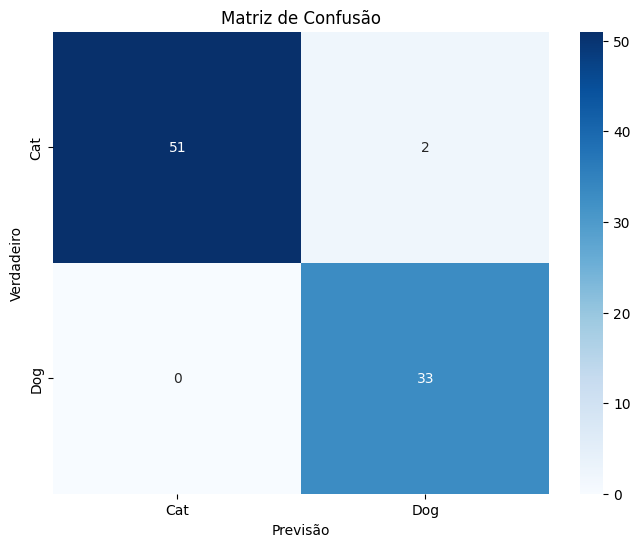

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

modelo.eval() # Coloca o modelo em modo de avaliação
all_labels = []
all_preds = []

with torch.no_grad():
    for imagens, etiquetas in valloader:
        logps = modelo(imagens.to(device))
        ps = torch.exp(logps)
        _, preds = torch.max(ps, 1)

        all_labels.extend(etiquetas.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# Calcula a matriz de confusão
cm = confusion_matrix(all_labels, all_preds)

# Obtém os nomes das classes
class_names = full_dataset.classes

# Plota a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()